# **<center style="color: green;">Desafío - Predicción de churn</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

# **Descripción**
En este proyecto de Machine Learning, se te ha encomendado la tarea de construir un
modelo de clasificación que determine si un paquete de ramen es "bueno" o "malo"
basándose en sus características específicas. Para ello, se proporciona un conjunto de
datos que contiene información sobre diferentes marcas de ramen y sus atributos, así como
una etiqueta que indica si el ramen fue considerado como "bueno" o "malo" por expertos o
usuarios.

In [1]:
# ==========================================
# 1. Importación de Librerías
# ==========================================
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Preprocesamiento y Evaluación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix)

# Scikit-Learn: Algoritmos de Clasificación 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# ==========================================
# 2. Carga del Dataset y Exploración Inicial
# ==========================================
try:
    # Cargar el archivo Excel
    df_ramen = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/4/Desafio/ramen-ratings.xlsx')
    print("✅ Dataset de Ramen cargado correctamente.\n")
    
    # Mostrar las primeras 5 filas
    display(df_ramen.head())
    
    # Mostrar información general para buscar nulos y tipos de datos
    print("\n--- Información general del dataset ---")
    df_ramen.info()
    
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'ramen-ratings.xlsx'. Asegúrate de que esté en la carpeta del proyecto en WSL.")
except Exception as e:
    print(f"❌ Ocurrió un error al cargar el archivo: {e}")

✅ Dataset de Ramen cargado correctamente.



,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   str   
 2   Variety   2580 non-null   str   
 3   Style     2578 non-null   str   
 4   Country   2580 non-null   str   
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     str   
dtypes: int64(1), object(1), str(5)
memory usage: 141.2+ KB


In [4]:
#Buscamos valores nulos
df_ramen.isnull().sum()

Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64

In [6]:
#Buscamos la cantidad de valores unicos que hay por columna
df_ramen.nunique()

Review #    2580
Brand        355
Variety     2412
Style          7
Country       38
Stars         43
Top Ten       38
dtype: int64

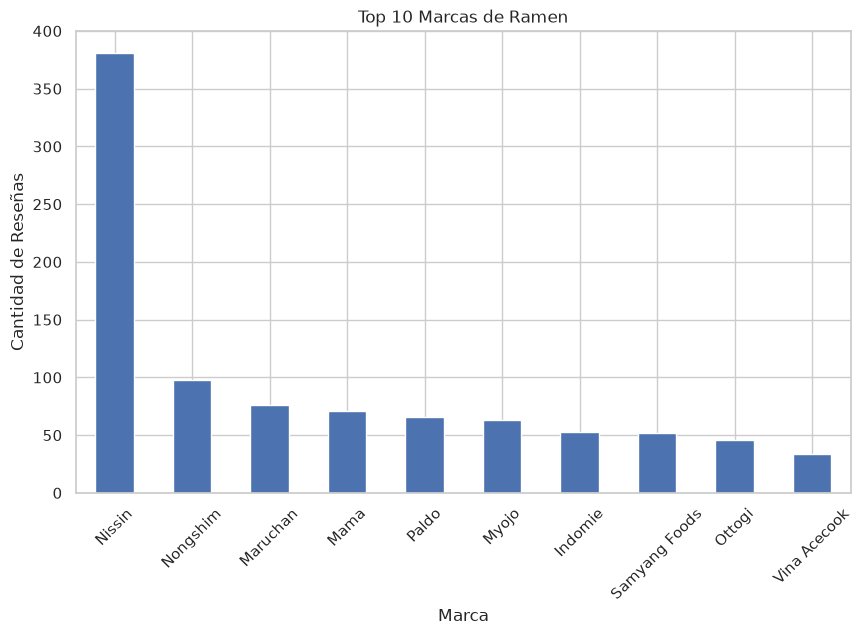

In [8]:
#Observamos la distribucion de valores en Brand
df_ramen['Brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Marcas de Ramen')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Reseñas')
plt.xticks(rotation=45)
plt.show()

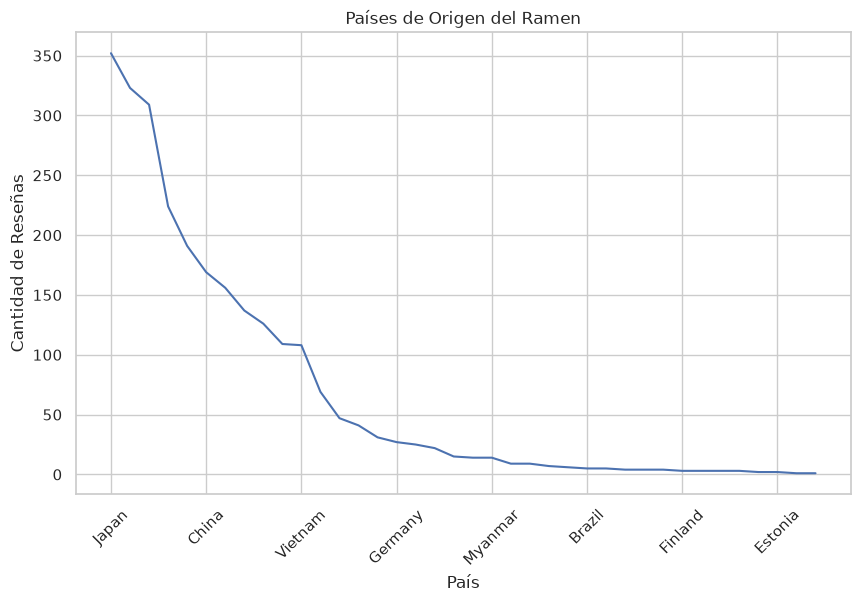

In [14]:
#Observamos la distribucion de valores en Country
df_ramen['Country'].value_counts().plot(kind='line')
plt.title('Países de Origen del Ramen')
plt.xlabel('País')
plt.ylabel('Cantidad de Reseñas')
plt.xticks(rotation=45)
plt.show()

# Limpieza de Datos y Creación del Target

In [15]:
# ==========================================
# 3. Limpieza de Datos y Creación del Target
# ==========================================

# Hacer una copia de seguridad para trabajar
df_ramen_clean = df_ramen.copy()

# Eliminar columnas que no aportan información relevante
df_ramen_clean = df_ramen_clean.drop(['Review #', 'Top Ten'], axis=1)

# Corregir la columna 'Stars' (de texto a numérico)
# El parámetro errors='coerce' convierte los textos como "Unrated" en valores nulos (NaN)
df_ramen_clean['Stars'] = pd.to_numeric(df_ramen_clean['Stars'], errors='coerce')

In [16]:
#Buscamos valores nulos
df_ramen_clean.isnull().sum()

Brand      0
Variety    0
Style      2
Country    0
Stars      3
dtype: int64

In [17]:
# Tratar los valores nulos (NaN)
# Como son muy pocos (los "Unrated" de Stars y 2 nulos en 'Style'), podemos eliminar esas filas
df_ramen_clean = df_ramen_clean.dropna()

In [18]:
#  Crear la Variable Objetivo (Calidad)
# Definimos: Bueno (1) >= 4.0 estrellas, Malo (0) < 4.0 estrellas
df_ramen_clean['Calidad'] = (df_ramen_clean['Stars'] >= 4.0).astype(int)

# Eliminamos la columna original 'Stars' para que el modelo no haga "trampa"
# (No podemos predecir si un ramen es bueno pasándole su calificación exacta)
df_ramen_clean = df_ramen_clean.drop(columns=['Stars'])

print("✅ Limpieza completada.")
print("\n--- Distribución de la nueva variable objetivo (Calidad) ---")
print(df_ramen_clean['Calidad'].value_counts(normalize=True) * 100)

print("\n--- Nueva estructura del dataset ---")
display(df_ramen_clean.head())

✅ Limpieza completada.

--- Distribución de la nueva variable objetivo (Calidad) ---
Calidad
0    56.23301
1    43.76699
Name: proportion, dtype: float64

--- Nueva estructura del dataset ---


,Brand,Variety,Style,Country,Calidad
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,0
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,0
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,0
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,0
4,Ching's Secret,Singapore Curry,Pack,India,0


# Preparación y División

In [20]:
# ==========================================
# 4. Transformación y Codificación 
# ==========================================

# 1. Label Encoding para variables de altísima cardinalidad
le_brand = LabelEncoder()
le_variety = LabelEncoder()

df_ramen_clean['Brand'] = le_brand.fit_transform(df_ramen_clean['Brand'])
df_ramen_clean['Variety'] = le_variety.fit_transform(df_ramen_clean['Variety'])

# 2. One-Hot Encoding para variables de baja cardinalidad
df_encoded = pd.get_dummies(df_ramen_clean, columns=['Style', 'Country'], drop_first=True)

# 3. Separar características (X) y variable objetivo (y)
X = df_encoded.drop('Calidad', axis=1)
y = df_encoded['Calidad']

# ==========================================
# 5. División y Escalado de Datos 
# ==========================================

# División 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de características (MUY IMPORTANTE para SVM y Regresión Logística)
# Nota: El escalador se entrena SOLO con X_train para evitar "fuga de datos" (data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos preprocesados, divididos y escalados con éxito.")
print(f"Dimensiones de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones de prueba: {X_test_scaled.shape}")

✅ Datos preprocesados, divididos y escalados con éxito.
Dimensiones de entrenamiento: (2060, 45)
Dimensiones de prueba: (515, 45)


# Modelado con Búsqueda de Hiperparámetros

In [21]:
# ==========================================
# 6. Entrenamiento y Optimización (Req. 2)
# ==========================================

# --- 1. Modelo: Regresión Logística ---
print("Optimizando Regresión Logística...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],          # Parámetro de regularización
    'solver': ['liblinear', 'lbfgs']       # Algoritmos de optimización
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                       param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print(f"✅ Mejor F1-Score LR: {grid_lr.best_score_:.4f}")
print(f"   Mejores hiperparámetros: {grid_lr.best_params_}\n")


# --- 2. Modelo: Support Vector Machine (SVM) ---
print("Optimizando Support Vector Machine (SVM)...")
param_grid_svm = {
    'C': [0.1, 1, 10],                     # Penalización por error
    'kernel': ['linear', 'rbf'],           # Tipo de frontera de decisión
    # gamma lo usa el kernel rbf, 'scale' es una buena opción por defecto
}

# Habilitamos probability=True porque luego el desafío pide calcular la métrica AUC-ROC
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), 
                        param_grid_svm, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
print(f"✅ Mejor F1-Score SVM: {grid_svm.best_score_:.4f}")
print(f"   Mejores hiperparámetros: {grid_svm.best_params_}")

Optimizando Regresión Logística...
✅ Mejor F1-Score LR: 0.5291
   Mejores hiperparámetros: {'C': 100, 'solver': 'liblinear'}

Optimizando Support Vector Machine (SVM)...


/home/cristian_tobar/proyectos/Latam_DataScience2024/env_Latam/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cristian_tobar/proyectos/Latam_DataScience2024/env_Latam/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cristian_tobar/proyectos/Latam_DataScience2024/env_Latam/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/cristian_tobar/proyect

✅ Mejor F1-Score SVM: 0.5695
   Mejores hiperparámetros: {'C': 1, 'kernel': 'rbf'}


--- Reporte de Clasificación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.65      0.73      0.69       290
           1       0.59      0.50      0.54       225

    accuracy                           0.63       515
   macro avg       0.62      0.61      0.61       515
weighted avg       0.62      0.63      0.62       515

---------------------------------------------

--- Reporte de Clasificación: SVM ---
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       290
           1       0.60      0.54      0.57       225

    accuracy                           0.64       515
   macro avg       0.63      0.63      0.63       515
weighted avg       0.64      0.64      0.64       515

---------------------------------------------



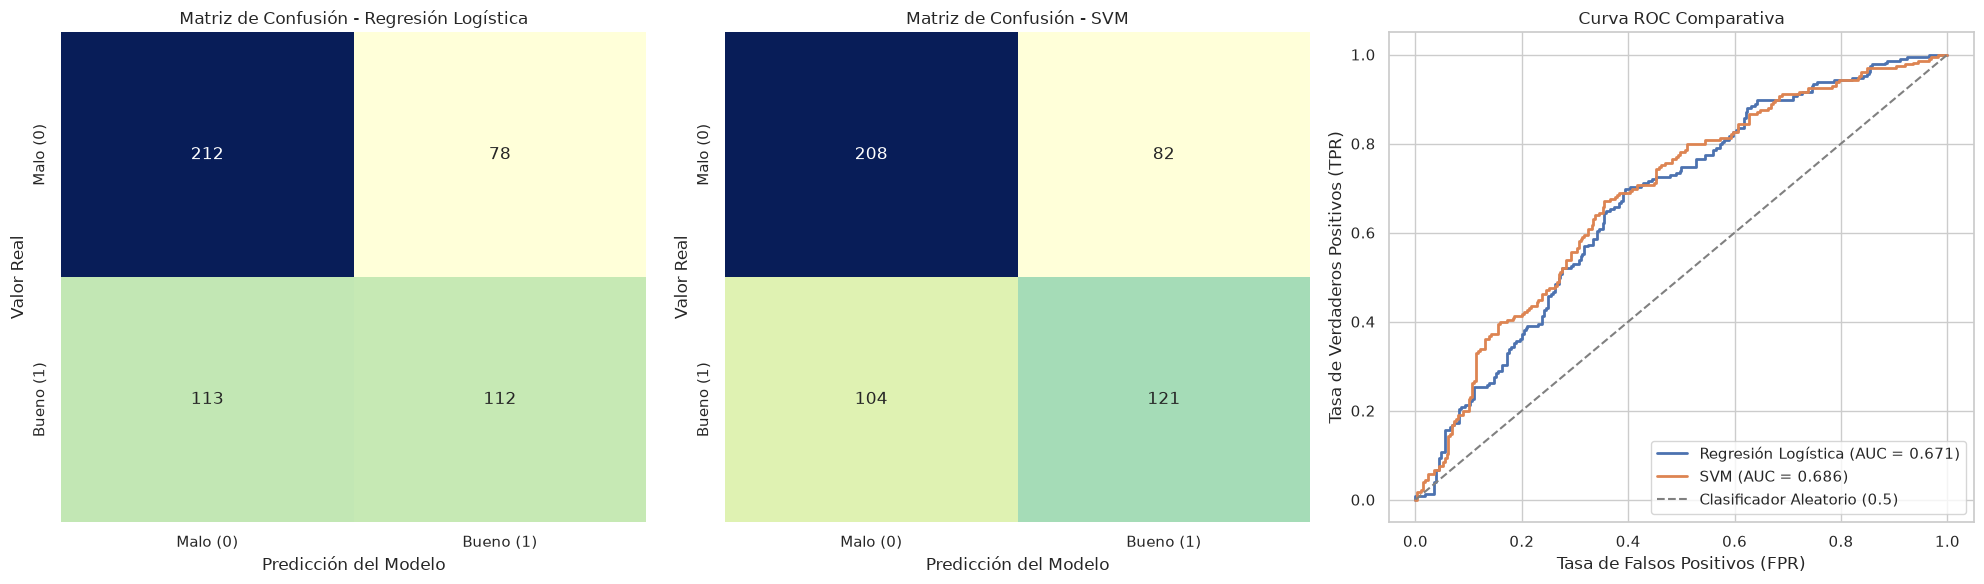


=== Tabla Resumen de Rendimiento ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
SVM,0.638835,0.596059,0.537778,0.565421,0.685732
Regresión Logística,0.629126,0.589474,0.497778,0.539759,0.671050


In [23]:
# ==========================================
# 7. Evaluación y Comparación de Modelos (Req. 3)
# ==========================================

# Diccionario para almacenar los resultados
resultados = {}
modelos = {'Regresión Logística': best_lr, 'SVM': best_svm}

# Preparar la figura: 1 fila, 3 columnas (2 Matrices + 1 Curva ROC)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (nombre, modelo) in enumerate(modelos.items()):
    # 1. Realizar predicciones de clase y de probabilidad
    y_pred = modelo.predict(X_test_scaled)
    # Probabilidad de la clase positiva (1 = Bueno) para el cálculo del AUC
    y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1] 
    
    # 2. Calcular métricas clave
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    resultados[nombre] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc}
    
    # 3. Mostrar reporte detallado en texto
    print(f"--- Reporte de Clasificación: {nombre} ---")
    print(classification_report(y_test, y_pred))
    print("-" * 45 + "\n")
    
    # 4. Graficar Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Matriz de Confusión - {nombre}')
    axes[idx].set_xlabel('Predicción del Modelo')
    axes[idx].set_ylabel('Valor Real')
    axes[idx].set_xticklabels(['Malo (0)', 'Bueno (1)'])
    axes[idx].set_yticklabels(['Malo (0)', 'Bueno (1)'])
    
    # 5. Calcular datos para la Curva ROC y agregarla al tercer panel
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[2].plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc:.3f})')

# Configuración final del panel de la Curva ROC
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador Aleatorio (0.5)')
axes[2].set_title('Curva ROC Comparativa')
axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

# ==========================================
# 8. Tabla Resumen Final
# ==========================================
print("\n=== Tabla Resumen de Rendimiento ===")
df_resultados = pd.DataFrame(resultados).T
display(df_resultados.sort_values(by='AUC-ROC', ascending=False))

# Conclusión Final: Análisis y Comparación de Modelos

El Modelo Support Vector Machine demostró ser el modelo superior para este conjunto de datos en todas las métricas evaluadas. Logró una exactitud (Accuracy) del 63.8% y un F1-Score del 56.5%, superando el 62.9% y 53.9% de la Regresión Logística, respectivamente.

Capacidad de Discriminación (AUC-ROC): La curva ROC confirma la superioridad del SVM. Con un AUC de 0.686 frente al 0.671 de la Regresión Logística, el SVM tiene una mejor capacidad intrínseca para separar correctamente la clase positiva (Ramen Bueno) de la negativa (Ramen Malo), independientemente del umbral de probabilidad elegido.

Análisis de la Matriz de Confusión (Recall vs. Falsos Positivos): Al observar las matrices, el SVM es notablemente mejor detectando los casos positivos reales. Logró identificar correctamente 121 ramen "buenos" frente a los solo 112 de la Regresión Logística. Esto se refleja en su Recall (53.7% vs 49.7%). Aunque el precio a pagar por esta mayor sensibilidad fue un ligero aumento en los falsos positivos (82 en SVM vs 78 en Regresión Logística), el balance general (F1-Score) sigue favoreciendo al SVM.

Reflexión sobre el Rendimiento General: Es importante notar que, aunque el SVM superó a su competidor, las métricas rondan el 60-68%. Esto tiene sentido desde la perspectiva del negocio: la calificación de un ramen (subjetividad del paladar humano) es difícil de predecir con alta precisión utilizando únicamente variables categóricas básicas como la "Marca", el "Estilo de envase" o el "País".

**Recomendación final:**  
Para este problema de clasificación específico, se recomienda la implementación del modelo Support Vector Machine (SVM) optimizado, ya que ofrece el mejor equilibrio predictivo. Para futuras iteraciones del proyecto y para superar la barrera del ~65% de exactitud, sería necesario enriquecer el conjunto de datos con características adicionales que dicten la calidad real del producto, tales como el nivel de sodio, el tipo de caldo, o los ingredientes específicos.